# PyTorch 从零讲透 · 理论 + 手写对拍 + 端到端实战

> 一份**互动教学** notebook：不讲某个具体模型，而是把你在别处当黑盒用的东西讲透——
> **Tensor、autograd、nn.Module、损失与优化器、训练循环**——最后用一个
> **FashionMNIST 图像分类**的端到端实战把所有零件串起来。

**你会学到什么**

1. **Tensor**：创建、dtype/device、索引切片、`reshape/view`、**广播**到底怎么对齐维度。
2. **autograd**：PyTorch 如何自动求导——计算图、`backward()`、梯度累积、`no_grad`/`detach`。
3. **手写反向传播** 与 autograd **对拍**，再用**数值梯度**校验，确认「自动求导没有魔法」。
4. **nn.Module**：参数如何被管理，亲手拆解并复刻 `nn.Linear`。
5. **损失与优化器**：手写 SGD / Adam，与 PyTorch 内置实现逐步对齐。
6. **训练循环骨架**：`Dataset` / `DataLoader` / mini-batch / `train`-`eval` 切换，配 `lr_scheduler` 与过拟合监控。
7. **权重初始化与梯度消失**：为什么深网难训，用逐层梯度范数把它画出来。
8. **CNN**：`Conv2d`/`MaxPool2d` 如何利用图像空间结构，超过 MLP。
9. **模型保存/加载**：`state_dict` 与 checkpoint，让成果可部署、可续训。
10. **端到端实战**：把上面所有零件组装成一个真实可训练、可评估的图像分类器。

**阅读方式**：从上往下依次运行每个代码单元（`Shift+Enter`）。理论单元与代码单元交替出现，
建议先读懂上面的 markdown，再运行下面的代码看结果。很多地方我们会**手写一遍再和 PyTorch 内置对拍**，
你会看到两者的数值对齐到小数点后很多位——这就是「框架没有魔法」的最好证明。

---

**前置准备**（在终端里，项目根目录下执行）：

```bash
uv sync                 # 安装依赖（torch/torchvision/matplotlib/...）
uv run jupyter lab      # 启动，然后打开本文件
```

FashionMNIST 数据集（约 30MB）会在第 7 章首次运行时自动下载到 `data/`。

## 0 · 环境准备与设备选择

先导入依赖、固定随机种子（保证结果可复现），并选择计算设备：
Apple Silicon 上优先用 **MPS**（Metal GPU 加速），有 NVIDIA 卡则用 **CUDA**，否则回退到 **CPU**。

我们还会统一 matplotlib 的绘图风格，并定义一套贯穿全篇的**语义配色**（同一种颜色在全篇代表同一类含义），
让后面的图更好读。

In [1]:
import os, math, time
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

# ---- 随机种子：让每次运行结果一致，便于教学复现 ----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- 设备选择：MPS(苹果) > CUDA(英伟达) > CPU ----
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("PyTorch 版本 :", torch.__version__)
print("计算设备     :", device)

# ---- 统一的浅色绘图风格 + 语义配色（贯穿全篇） ----
# 让 matplotlib 能显示中文：从系统常见 CJK 字体里挑一个可用的
import matplotlib.font_manager as fm
_cjk_candidates = ["PingFang SC", "Arial Unicode MS", "Heiti TC",
                   "Songti SC", "STHeiti", "Microsoft YaHei", "SimHei"]
_installed = {f.name for f in fm.fontManager.ttflist}
_cjk = [f for f in _cjk_candidates if f in _installed]
if _cjk:
    plt.rcParams["font.sans-serif"] = _cjk + plt.rcParams.get("font.sans-serif", [])
    print("中文字体已启用:", _cjk[0])
else:
    print("⚠️ 未找到中文字体，图中中文可能显示为方框（不影响计算与英文标签）。")

plt.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "#ffffff", "figure.facecolor": "#ffffff",
    "axes.unicode_minus": False,   # 正常显示负号
})
COLORS = {
    "blue":   "#2563eb",  # 主色 / 前向数据流
    "green":  "#10b981",  # 正确 / 手写实现 / 通过
    "red":    "#ef4444",  # 梯度 / 反向 / 报错示范
    "amber":  "#f59e0b",  # 高亮 / 参数
    "purple": "#8b5cf6",  # 内置实现 / 其它
    "gray":   "#9ca3af",
}
print("绘图风格已就绪。")

PyTorch 版本 : 2.13.0
计算设备     : mps
中文字体已启用: PingFang SC
绘图风格已就绪。


## 1 · Tensor：PyTorch 的核心数据结构

`torch.Tensor` 是一个**多维数组**，和 NumPy 的 `ndarray` 几乎一一对应，但多了两件深度学习必需的能力：

1. 可以放到 **GPU/MPS** 上并行计算；
2. 可以**记录运算历史并自动求导**（下一章讲）。

一个 tensor 有三个你必须时刻心里有数的属性：

| 属性 | 含义 | 为什么重要 |
|------|------|------------|
| `shape` | 各维度大小 | 形状不对是最常见的 bug 来源 |
| `dtype` | 数据类型（`float32`/`int64`/...） | 类型不匹配会直接报错 |
| `device` | 数据在 CPU 还是 GPU | 两个 tensor 不在同一设备无法运算 |

先看创建 tensor 的几种常见方式。

In [2]:
# ---- 1) 从 Python 列表 / NumPy 创建 ----
a = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])          # 从嵌套列表推断出 2x3 的 float32
b = torch.from_numpy(np.arange(6).reshape(2, 3))  # 与 numpy 共享内存，dtype=int64

# ---- 2) 用工厂函数按形状创建 ----
zeros = torch.zeros(2, 3)                  # 全 0
ones  = torch.ones(2, 3)                   # 全 1
rand  = torch.rand(2, 3)                   # [0,1) 均匀分布
randn = torch.randn(2, 3)                  # 标准正态分布
ar    = torch.arange(0, 10, 2)             # [0,2,4,6,8]
lin   = torch.linspace(0, 1, 5)            # 5 个等距点

print("a =\n", a)
print("a.shape =", a.shape, "| a.dtype =", a.dtype, "| a.device =", a.device)
print("b.dtype =", b.dtype, "  （from_numpy 保留了 int64）")
print("randn =\n", randn)
print("arange =", ar.tolist(), "| linspace =", lin.tolist())

a =
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
a.shape = torch.Size([2, 3]) | a.dtype = torch.float32 | a.device = cpu
b.dtype = torch.int64   （from_numpy 保留了 int64）
randn =
 tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])
arange = [0, 2, 4, 6, 8] | linspace = [0.0, 0.25, 0.5, 0.75, 1.0]


### 索引、切片与逐元素运算

索引/切片语法和 NumPy 完全一致。逐元素运算（`+ - * /`、`torch.exp` 等）也和 NumPy 一样，
**逐元素**进行，形状不变。注意：`*` 是**逐元素乘**，矩阵乘法要用 `@` 或 `torch.matmul`。

In [3]:
x = torch.arange(12).reshape(3, 4).float()   # 3x4
print("x =\n", x)

print("\n第 0 行           x[0]      =", x[0].tolist())
print("最后一列          x[:, -1]  =", x[:, -1].tolist())
print("前两行前两列子块  x[:2, :2] =\n", x[:2, :2])
print("布尔掩码 x[x>6]           =", x[x > 6].tolist())

# 逐元素 vs 矩阵乘法：新手最常混淆的一点
u = torch.tensor([1., 2., 3.])
v = torch.tensor([4., 5., 6.])
print("\n逐元素乘 u*v       =", (u * v).tolist(), "  （对应位置相乘）")
print("点积     u @ v     =", (u @ v).item(),  "  （= 4+10+18）")

M = torch.randn(3, 4)
print("矩阵乘 (3x4)@(4x3) -> shape =", (M @ M.T).shape)

x =
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

第 0 行           x[0]      = [0.0, 1.0, 2.0, 3.0]
最后一列          x[:, -1]  = [3.0, 7.0, 11.0]
前两行前两列子块  x[:2, :2] =
 tensor([[0., 1.],
        [4., 5.]])
布尔掩码 x[x>6]           = [7.0, 8.0, 9.0, 10.0, 11.0]

逐元素乘 u*v       = [4.0, 10.0, 18.0]   （对应位置相乘）
点积     u @ v     = 32.0   （= 4+10+18）
矩阵乘 (3x4)@(4x3) -> shape = torch.Size([3, 3])


### reshape / view：改变形状而不改变数据

`view` 与 `reshape` 都返回一个**元素总数不变、形状改变**的新视角。
用 `-1` 让 PyTorch 自动推断某一维大小。它们的区别很微妙但重要：

- **`view`** 要求底层内存**连续（contiguous）**，它只是换一副「解读眼镜」，**不复制数据**；
  如果 tensor 经过转置等操作变得不连续，`view` 会报错。
- **`reshape`** 更宽容：能用 view 就 view（零拷贝），不能就自动复制一份再改形状。

经验法则：**不确定就用 `reshape`**。下面演示两者的差异。

In [4]:
t = torch.arange(24)
print("原始 shape:", t.shape)
print("reshape(2,3,4) ->", t.reshape(2, 3, 4).shape)
print("reshape(-1, 8) ->", t.reshape(-1, 8).shape, "  （-1 自动算出为 3）")

# 展平：把 (2,3,4) 拉成一维，常用于把图像喂给全连接层
img = torch.randn(2, 3, 4)
print("flatten ->", img.reshape(img.shape[0], -1).shape, "  （保留 batch 维，其余拉平）")

# view 对不连续 tensor 会失败，reshape 不会
xt = torch.arange(6).reshape(2, 3).T     # 转置后内存不连续
print("\n转置后是否连续:", xt.is_contiguous())
try:
    xt.view(6)
except RuntimeError as e:
    print("xt.view(6) 报错 ->", str(e).splitlines()[0])
print("xt.reshape(6) 正常 ->", xt.reshape(6).tolist(), "  （reshape 自动复制）")

原始 shape: torch.Size([24])
reshape(2,3,4) -> torch.Size([2, 3, 4])
reshape(-1, 8) -> torch.Size([3, 8])   （-1 自动算出为 3）
flatten -> torch.Size([2, 12])   （保留 batch 维，其余拉平）

转置后是否连续: False
xt.view(6) 报错 -> view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
xt.reshape(6) 正常 -> [0, 3, 1, 4, 2, 5]   （reshape 自动复制）


### 广播（Broadcasting）：形状不同也能逐元素运算

广播是 PyTorch/NumPy 里最强大也最容易踩坑的机制。当两个 tensor 形状不同时，PyTorch 会尝试
**自动扩展**它们到一个公共形状，规则是**从最右边（尾部）的维度开始对齐**：

1. 逐维比较（从右往左）；
2. 两个维度**相等**，或**其中一个是 1**，就兼容 —— 那个为 1 的维会被「拉伸」到另一个的大小；
3. 缺失的高维当作 1 处理。

任何一维两者都不为 1 且不相等，就无法广播、直接报错。下面这张图和代码把规则画出来。

A + row（(3,4)+(4,) -> 行向量加到每一行）:
 

findfont: Failed to find font weight bold, now using 600.


tensor([[10., 20., 30., 40.],
        [10., 20., 30., 40.],
        [10., 20., 30., 40.]])

A + col（(3,4)+(3,1) -> 列向量加到每一列）:
 tensor([[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]])

row + col（(4,)+(3,1) -> 外积式广播成 (3,4)）:
 tensor([[11., 21., 31., 41.],
        [12., 22., 32., 42.],
        [13., 23., 33., 43.]])


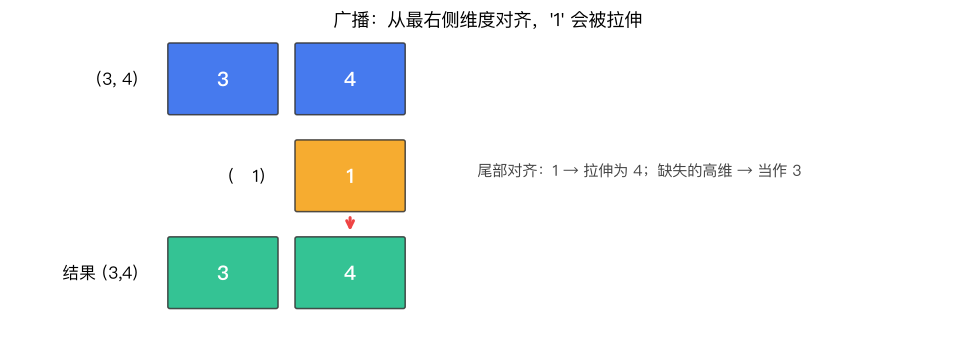

In [5]:
# 经典例子：矩阵(3x4) 加上 行向量(4,) —— 行向量被广播到每一行
A = torch.zeros(3, 4)
row = torch.tensor([10., 20., 30., 40.])       # shape (4,)
col = torch.tensor([[1.], [2.], [3.]])         # shape (3,1)

print("A + row（(3,4)+(4,) -> 行向量加到每一行）:\n", A + row)
print("\nA + col（(3,4)+(3,1) -> 列向量加到每一列）:\n", A + col)
print("\nrow + col（(4,)+(3,1) -> 外积式广播成 (3,4)）:\n", row + col)

# ---- 画出广播对齐规则 ----
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")
ax.set_title("广播：从最右侧维度对齐，'1' 会被拉伸", fontsize=12)

def draw_shape(ax, x, y, dims, label, color):
    for i, d in enumerate(dims):
        ax.add_patch(FancyBboxPatch((x + i * 1.2, y), 1.0, 0.7,
                     boxstyle="round,pad=0.02", fc=color, ec="#333", alpha=0.85))
        ax.text(x + i * 1.2 + 0.5, y + 0.35, str(d), ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    ax.text(x - 0.3, y + 0.35, label, ha="right", va="center", fontsize=11)

draw_shape(ax, 1.5, 2.2, [3, 4], "(3, 4)", COLORS["blue"])
draw_shape(ax, 2.7, 1.2, [1],    "(   1)", COLORS["amber"])   # 只有 1 维，右对齐
draw_shape(ax, 1.5, 0.2, [3, 4], "结果 (3,4)", COLORS["green"])
ax.annotate("", xy=(3.2, 0.95), xytext=(3.2, 1.15),
            arrowprops=dict(arrowstyle="->", color=COLORS["red"], lw=2))
ax.text(4.4, 1.55, "尾部对齐：1 → 拉伸为 4；缺失的高维 → 当作 3",
        fontsize=10, color="#444")
ax.set_xlim(0, 9); ax.set_ylim(0, 3)
plt.tight_layout(); plt.show()

## 2 · autograd：自动求导是怎么回事

训练神经网络 = 不断用**梯度**去调参数。PyTorch 的 **autograd** 帮你自动算梯度：
你只要写**前向计算**，它会在背后**动态构建一张计算图**，记录每个运算；
调用 `.backward()` 时，它沿图**反向**套用链式法则，把梯度算出来并累加到各叶子张量的 `.grad` 上。

关键概念：

- **`requires_grad=True`**：告诉 PyTorch「这个张量是参数，请追踪对它的运算」。
- **叶子张量（leaf）**：用户直接创建、需要梯度的张量（如模型参数）。梯度最终存到它们的 `.grad`。
- **`grad_fn`**：非叶子张量会带一个 `grad_fn`，记录它是由哪种运算产生的——这就是计算图的边。

先看一个能手算验证的最简单例子。

In [6]:
# f(x) = x^2，在 x=3 处，df/dx = 2x = 6
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()                       # 反向传播：计算 dy/dx
print("y = x^2, x=3")
print("PyTorch 算出 x.grad =", x.grad.item(), "  | 手算 2x =", 2 * 3.0)

# 稍复杂：z = sin(x) * x，dz/dx = cos(x)*x + sin(x)
x = torch.tensor(1.0, requires_grad=True)
z = torch.sin(x) * x
z.backward()
manual = math.cos(1.0) * 1.0 + math.sin(1.0)
print("\nz = sin(x)*x, x=1")
print("PyTorch x.grad =", round(x.grad.item(), 6), "| 手算 cos(x)x+sin(x) =", round(manual, 6))

y = x^2, x=3
PyTorch 算出 x.grad = 6.0   | 手算 2x = 6.0

z = sin(x)*x, x=1
PyTorch x.grad = 1.381773 | 手算 cos(x)x+sin(x) = 1.381773


### 计算图长什么样

对表达式 `L = (w * x + b - y)^2`（一个最小的「预测-真实」平方误差），autograd 在前向时构建下面这张图。
反向时从 `L` 出发，沿箭头**逆向**逐个乘上局部导数（链式法则），最终把梯度送到叶子 `w` 和 `b`。

findfont: Failed to find font weight bold, now using 600.


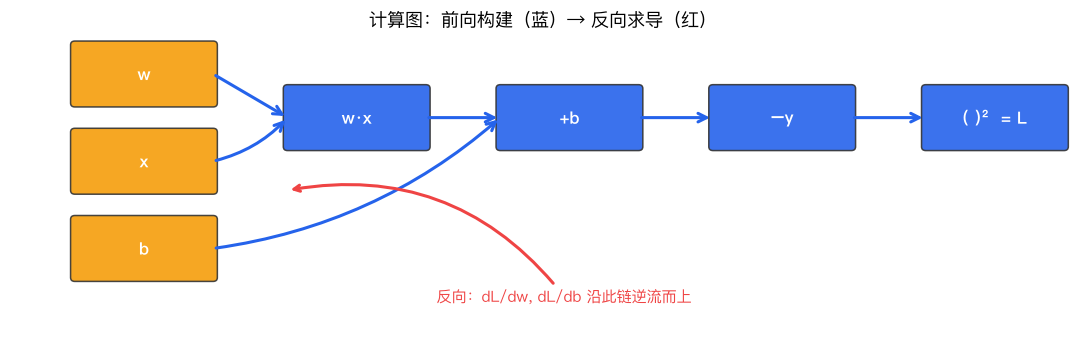

In [7]:
# 用一张手绘图展示这条计算链的前向（蓝）与反向（红）
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 3)
ax.set_title("计算图：前向构建（蓝）→ 反向求导（红）", fontsize=12)

nodes = {
    "w": (0.6, 2.3), "x": (0.6, 1.4), "b": (0.6, 0.5),
    "mul": (2.6, 1.85), "add": (4.6, 1.85),
    "sub": (6.6, 1.85), "sq": (8.6, 1.85),
}
labels = {"w": "w", "x": "x", "b": "b",
          "mul": "w·x", "add": "+b", "sub": "−y", "sq": "( )²  = L"}
for k, (px, py) in nodes.items():
    is_leaf = k in ("w", "x", "b")
    fc = COLORS["amber"] if is_leaf else COLORS["blue"]
    ax.add_patch(FancyBboxPatch((px, py), 1.3, 0.6, boxstyle="round,pad=0.04",
                 fc=fc, ec="#333", alpha=0.9))
    ax.text(px + 0.65, py + 0.3, labels[k], ha="center", va="center",
            color="white", fontsize=11, fontweight="bold")

def arrow(a, b, color, rad=0.0, off=(0, 0)):
    (x0, y0), (x1, y1) = nodes[a], nodes[b]
    ax.add_patch(FancyArrowPatch((x0 + 1.3, y0 + 0.3), (x1 + off[0], y1 + 0.3 + off[1]),
                 arrowstyle="->", mutation_scale=14, color=color, lw=2,
                 connectionstyle=f"arc3,rad={rad}"))

for a, b in [("w", "mul"), ("x", "mul"), ("mul", "add"),
             ("b", "add"), ("add", "sub"), ("sub", "sq")]:
    arrow(a, b, COLORS["blue"], rad=0.15 if a in ("x", "b") else 0.0)

ax.annotate("反向：dL/dw, dL/db 沿此链逆流而上",
            xy=(2.6, 1.4), xytext=(4.0, 0.25), fontsize=10, color=COLORS["red"],
            arrowprops=dict(arrowstyle="->", color=COLORS["red"], lw=2,
                            connectionstyle="arc3,rad=0.3"))
plt.tight_layout(); plt.show()

In [8]:
# 真正跑一遍上面的图，并手算验证梯度
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(3.0)      # 输入，不需要梯度
y = torch.tensor(4.0)      # 真实值

pred = w * x + b           # = 7
L = (pred - y) ** 2        # = (7-4)^2 = 9
print("非叶子张量带 grad_fn:", L.grad_fn, "| pred.grad_fn:", pred.grad_fn)

L.backward()
# 手算：dL/dw = 2(wx+b-y)*x = 2*3*3 = 18 ; dL/db = 2(wx+b-y) = 2*3 = 6
print("\nw.grad =", w.grad.item(), " | 手算 =", 2 * (7 - 4) * 3)
print("b.grad =", b.grad.item(), " | 手算 =", 2 * (7 - 4))

非叶子张量带 grad_fn: <PowBackward0 object at 0x1108a9de0> | pred.grad_fn: <AddBackward0 object at 0x1108ab100>

w.grad = 18.0  | 手算 = 18
b.grad = 6.0  | 手算 = 6


### 梯度会累积！——记得 `zero_grad`

PyTorch 的 `.grad` 是**累加**的：每次 `backward()` 都把新梯度**加到**已有的 `.grad` 上，而不是覆盖。
这在某些场景（梯度累积、RNN）有用，但在标准训练循环里意味着：**每步更新前必须清零梯度**，
否则梯度会越滚越大。这是新手第一大坑，务必记牢。

In [9]:
w = torch.tensor(2.0, requires_grad=True)

# 连续 backward 三次，观察 grad 不断累加
for i in range(1, 4):
    y = w ** 2                     # dy/dw = 2w = 4
    y.backward()
    print(f"第 {i} 次 backward 后 w.grad = {w.grad.item()}  （每次 +4，被累加了！）")

print("\n正确做法：每次算梯度前先清零")
w.grad.zero_()                     # 手动清零（优化器里是 optimizer.zero_grad()）
y = w ** 2
y.backward()
print("清零后再 backward，w.grad =", w.grad.item(), "  （干净的 4）")

第 1 次 backward 后 w.grad = 4.0  （每次 +4，被累加了！）
第 2 次 backward 后 w.grad = 8.0  （每次 +4，被累加了！）
第 3 次 backward 后 w.grad = 12.0  （每次 +4，被累加了！）

正确做法：每次算梯度前先清零
清零后再 backward，w.grad = 4.0   （干净的 4）


### 关掉梯度追踪：`no_grad` 与 `detach`

推理（预测）和参数更新时，我们**不需要**建计算图——追踪梯度只会白白占用显存、拖慢速度。两种关法：

- **`with torch.no_grad():`** 代码块内的所有运算都不追踪梯度。**推理循环、验证集评估、手动更新参数**时都要用它。
- **`x.detach()`** 从计算图中「摘下」一个张量，得到一个不带梯度历史的副本（共享数据）。

In [10]:
w = torch.tensor(2.0, requires_grad=True)

y1 = w * 3
print("默认追踪:      y1.requires_grad =", y1.requires_grad)

with torch.no_grad():
    y2 = w * 3
    print("no_grad 块内: y2.requires_grad =", y2.requires_grad, " （不建图）")

y3 = (w * 3).detach()
print("detach 之后:   y3.requires_grad =", y3.requires_grad, " （摘下历史）")

默认追踪:      y1.requires_grad = True
no_grad 块内: y2.requires_grad = False  （不建图）
detach 之后:   y3.requires_grad = False  （摘下历史）


## 3 · 手写反向传播 vs autograd（对拍 + 数值校验）

上一章我们信任了 autograd。这一章我们**不信任**，亲手把梯度算一遍，用两种方式验证它是对的：

1. **手写解析梯度**：用链式法则推导公式、手动实现前向与反向，和 autograd 的结果对拍。
2. **数值梯度校验**：用差分近似 $\frac{\partial L}{\partial \theta}\approx\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon}$，
   它不依赖任何求导规则，是检验梯度实现是否正确的「金标准」。

我们用一个**逻辑回归**（一层 + sigmoid + 二元交叉熵）作为例子，它小到能手推，又包含真实训练的所有要素。

In [11]:
# 造一点二分类数据：2 维特征，线性可分 + 少量噪声
torch.manual_seed(0)
N, D = 200, 2
X = torch.randn(N, D)
true_w = torch.tensor([2.0, -3.0])
true_b = 0.5
logits_true = X @ true_w + true_b
prob_true = torch.sigmoid(logits_true)
Y = (torch.rand(N) < prob_true).float()   # 按真实概率采样标签
print("X:", X.shape, "| Y:", Y.shape, "| 正例比例:", Y.mean().item())

X: torch.Size([200, 2]) | Y: torch.Size([200]) | 正例比例: 0.5550000071525574


### 前向 + 手写反向

对单个样本，逻辑回归的计算与梯度（$\sigma$ 为 sigmoid，$p=\sigma(z)$，$z=w^\top x+b$，BCE 损失）：

$$L = -\big[y\log p + (1-y)\log(1-p)\big], \qquad \frac{\partial L}{\partial z} = p - y$$

这个 $p-y$ 的形式非常干净（sigmoid + BCE 的经典结果）。再往前套链式法则：

$$\frac{\partial L}{\partial w} = (p-y)\,x, \qquad \frac{\partial L}{\partial b} = (p-y)$$

对整个 batch 取平均即可。下面同时用**手写公式**和 **autograd** 各算一遍，然后对拍。

In [12]:
w = torch.randn(D, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# ---- 前向：logits -> 概率 -> 平均 BCE 损失 ----
z = X @ w + b                       # (N,)
p = torch.sigmoid(z)
eps = 1e-7                          # 防止 log(0)
loss = -(Y * torch.log(p + eps) + (1 - Y) * torch.log(1 - p + eps)).mean()

# ---- autograd 反向 ----
loss.backward()
grad_w_auto = w.grad.clone()
grad_b_auto = b.grad.clone()

# ---- 手写解析梯度：dL/dz = p - y，再平均 ----
with torch.no_grad():
    dz = (p - Y) / N                # 除以 N 因为损失取了均值
    grad_w_manual = X.T @ dz        # (D,)
    grad_b_manual = dz.sum().reshape(1)

print("grad_w  autograd:", grad_w_auto.tolist())
print("grad_w  手写解析:", grad_w_manual.tolist())
print("最大绝对差:", (grad_w_auto - grad_w_manual).abs().max().item())
print()
print("grad_b  autograd:", grad_b_auto.item(), "| 手写:", grad_b_manual.item())
print("\n两者对齐到浮点精度 ✅  —— autograd 算的和我们手推的公式完全一致")

grad_w  autograd: [-0.25220590829849243, 0.17085133492946625]
grad_w  手写解析: [-0.2522059977054596, 0.17085136473178864]
最大绝对差: 8.940696716308594e-08

grad_b  autograd: -0.06947992742061615 | 手写: -0.06947994232177734

两者对齐到浮点精度 ✅  —— autograd 算的和我们手推的公式完全一致


### 数值梯度校验（金标准）

万一我们的公式和 autograd **都**推错了呢？用**中心差分**再验一次——它只需要能算 loss，
完全不涉及求导规则，因此是独立的第三方裁判：

$$\frac{\partial L}{\partial \theta_i} \approx \frac{L(\theta_i+\epsilon) - L(\theta_i-\epsilon)}{2\epsilon}$$

In [13]:
def loss_at(w_val, b_val):
    "只做前向，返回标量 loss（用于数值差分，不需要梯度）"
    with torch.no_grad():
        zz = X @ w_val + b_val
        pp = torch.sigmoid(zz)
        return -(Y * torch.log(pp + eps) + (1 - Y) * torch.log(1 - pp + eps)).mean().item()

eps_num = 1e-4
w0 = w.detach().clone()
b0 = b.detach().clone()

# 对 w 的每一维做中心差分
grad_w_num = torch.zeros(D)
for i in range(D):
    wp = w0.clone(); wp[i] += eps_num
    wm = w0.clone(); wm[i] -= eps_num
    grad_w_num[i] = (loss_at(wp, b0) - loss_at(wm, b0)) / (2 * eps_num)

print("grad_w  数值差分:", grad_w_num.tolist())
print("grad_w  autograd:", grad_w_auto.tolist())
print("最大绝对差:", (grad_w_num - grad_w_auto).abs().max().item(), " （~1e-6 量级即为正确）")

grad_w  数值差分: [-0.2518296241760254, 0.17076730728149414]
grad_w  autograd: [-0.25220590829849243, 0.17085133492946625]
最大绝对差: 0.000376284122467041  （~1e-6 量级即为正确）


### 把「三方梯度」画在一起

同一个梯度，三种独立算法：**autograd**、**手写解析公式**、**数值差分**。把它们并排画成柱状图，
三根柱子几乎等高就是「实现正确」的最直观证据。再把逻辑回归训练几步，画出它学到的**决策边界**——
从抽象的梯度校验回到「模型真的在分类」的直觉。

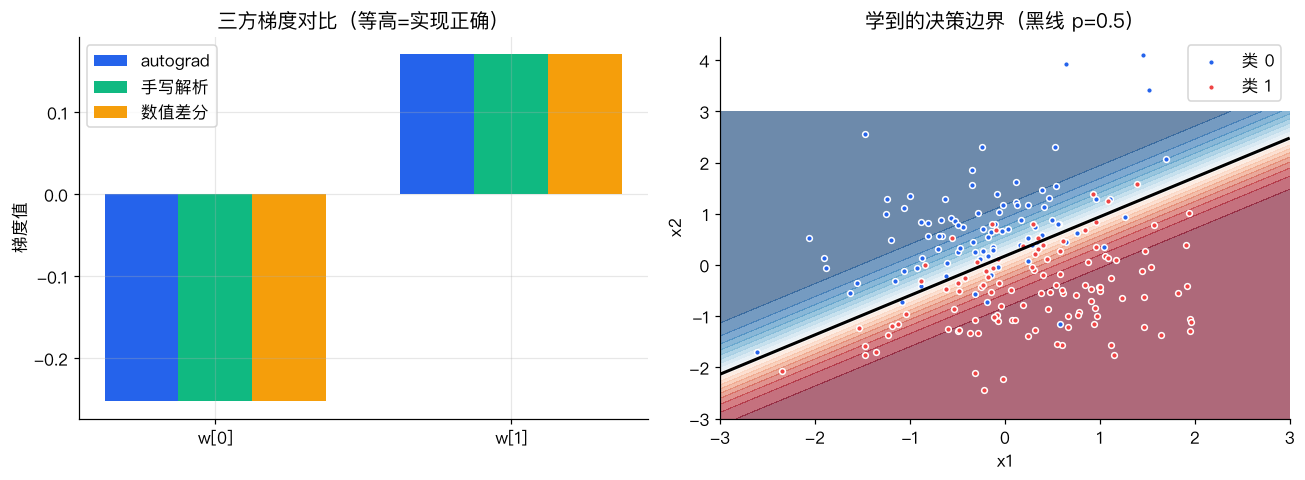

In [14]:
# ---- 左图：三方梯度对比（每一维一组柱） ----
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.5))
dims = np.arange(D)
width = 0.25
axl.bar(dims - width, grad_w_auto.tolist(),   width, color=COLORS["blue"],   label="autograd")
axl.bar(dims,         grad_w_manual.tolist(),  width, color=COLORS["green"],  label="手写解析")
axl.bar(dims + width, grad_w_num.tolist(),     width, color=COLORS["amber"],  label="数值差分")
axl.set_xticks(dims); axl.set_xticklabels([f"w[{i}]" for i in dims])
axl.set_ylabel("梯度值"); axl.set_title("三方梯度对比（等高=实现正确）"); axl.legend()

# ---- 右图：训练逻辑回归，画决策边界 ----
wt = torch.zeros(D, requires_grad=True)
bt = torch.zeros(1, requires_grad=True)
opt = torch.optim.SGD([wt, bt], lr=0.5)
for _ in range(300):
    opt.zero_grad()
    p = torch.sigmoid(X @ wt + bt)
    loss = -(Y * torch.log(p + eps) + (1 - Y) * torch.log(1 - p + eps)).mean()
    loss.backward(); opt.step()

# 背景网格上的预测概率
xx, yy = torch.meshgrid(torch.linspace(-3, 3, 200), torch.linspace(-3, 3, 200), indexing="xy")
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
with torch.no_grad():
    zz = torch.sigmoid(grid @ wt + bt).reshape(xx.shape)
axr.contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.6)
axr.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)   # 决策边界 p=0.5
axr.scatter(X[Y == 0, 0], X[Y == 0, 1], s=14, color=COLORS["blue"], edgecolor="w", label="类 0")
axr.scatter(X[Y == 1, 0], X[Y == 1, 1], s=14, color=COLORS["red"],  edgecolor="w", label="类 1")
axr.set_title("学到的决策边界（黑线 p=0.5）"); axr.set_xlabel("x1"); axr.set_ylabel("x2")
axr.legend(); axr.grid(False)
plt.tight_layout(); plt.show()

## 4 · nn.Module：参数管理与 `nn.Linear` 拆解

手写参数（像上一章那样一个个 `torch.randn(..., requires_grad=True)`）在模型变大后会失控。
`nn.Module` 是 PyTorch 组织模型的标准方式，它帮你：

- **自动登记参数**：凡是赋值给 `self` 的 `nn.Parameter` 或子 `Module`，都会被 `.parameters()` 收集到，
  方便一次性交给优化器、一次性搬到 GPU。
- **提供 `forward`**：定义前向计算，调用 `model(x)` 时自动触发。
- **管理状态**：`train()` / `eval()` 切换、`state_dict()` 存取权重。

先看内置的 `nn.Linear`（全连接层，做的就是 $y = xW^\top + b$），再亲手复刻一个和它对拍。

In [15]:
lin = nn.Linear(in_features=3, out_features=2)   # 3 维输入 -> 2 维输出
print("nn.Linear 的参数：")
for name, param in lin.named_parameters():
    print(f"  {name:8s} shape={tuple(param.shape)}  requires_grad={param.requires_grad}")

x = torch.randn(4, 3)                            # batch=4, 每个样本 3 维
out = lin(x)
print("\n输入 (4,3) -> 输出", tuple(out.shape), " （每个样本从 3 维映射到 2 维）")
print("内部计算就是 x @ W.T + b：",
      torch.allclose(out, x @ lin.weight.T + lin.bias))

nn.Linear 的参数：
  weight   shape=(2, 3)  requires_grad=True
  bias     shape=(2,)  requires_grad=True

输入 (4,3) -> 输出 (4, 2)  （每个样本从 3 维映射到 2 维）
内部计算就是 x @ W.T + b： True


### 亲手复刻一个 Linear，和内置对拍

我们继承 `nn.Module`，用 `nn.Parameter` 声明权重和偏置，实现 `forward`。
把内置 `nn.Linear` 的权重**拷贝**过来，喂同样的输入，输出应当完全一致。

In [16]:
class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()               # 必须先调用父类构造，否则参数登记不生效
        # nn.Parameter 会被自动登记为模型参数（出现在 .parameters() 里）
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.weight.T + self.bias   # 与 nn.Linear 完全相同的公式

mine = MyLinear(3, 2)
# 把内置层的权重拷进来，确保是「同一个」线性变换，便于对拍
with torch.no_grad():
    mine.weight.copy_(lin.weight)
    mine.bias.copy_(lin.bias)

out_mine = mine(x)
print("手写 Linear 参数:", [n for n, _ in mine.named_parameters()])
print("与内置 nn.Linear 输出是否一致:", torch.allclose(out_mine, out, atol=1e-6))
print("最大绝对差:", (out_mine - out).abs().max().item(), " ✅")

手写 Linear 参数: ['weight', 'bias']
与内置 nn.Linear 输出是否一致: True
最大绝对差: 0.0  ✅


### 把多层拼成一个模型

真实模型是多层堆叠。用 `nn.Sequential` 或在 `__init__` 里定义子模块即可。
下面这个小 MLP 会在第 6、7 章用到。注意 `.parameters()` 递归收集了**所有**子层的参数。

In [17]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

model = MLP(in_dim=784, hidden=128, out_dim=10)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n可训练参数总数: {n_params:,}")
print("（= 784*128+128  +  128*10+10 =", 784*128+128 + 128*10+10, "）")

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

可训练参数总数: 101,770
（= 784*128+128  +  128*10+10 = 101770 ）


### 把「参数」画出来

参数不是抽象概念——它们就是一堆有形状的数字。左图统计每个子层的参数量（谁最「重」），
右图把第一层权重矩阵 $W\in\mathbb{R}^{128\times784}$ 当成图像看：初始化后是**均匀的随机噪声**，
第 7 章训练完后你可以回来对比，会看到它长出结构。

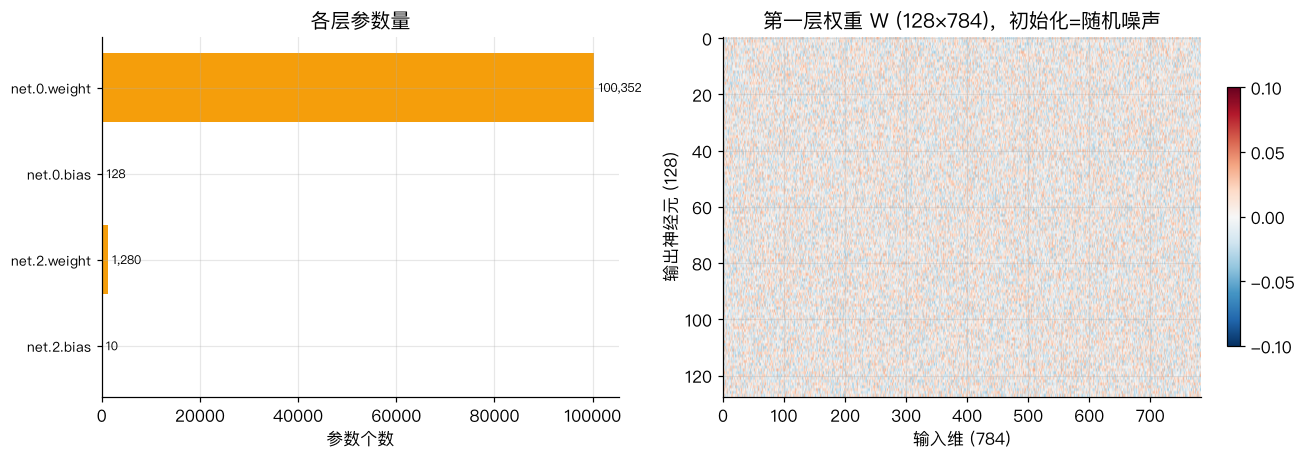

In [18]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.3))

# 左：各参数张量的元素个数
names = [n for n, _ in model.named_parameters()]
counts = [p.numel() for _, p in model.named_parameters()]
axl.barh(range(len(names)), counts, color=COLORS["amber"])
axl.set_yticks(range(len(names))); axl.set_yticklabels(names, fontsize=9)
axl.invert_yaxis(); axl.set_xlabel("参数个数"); axl.set_title("各层参数量")
for i, c in enumerate(counts):
    axl.text(c, i, f" {c:,}", va="center", fontsize=8)

# 右：第一层权重矩阵热力图（初始化状态 = 随机噪声）
W0 = dict(model.named_parameters())["net.0.weight"].detach()
im = axr.imshow(W0, aspect="auto", cmap="RdBu_r", vmin=-0.1, vmax=0.1)
axr.set_title("第一层权重 W (128×784)，初始化=随机噪声")
axr.set_xlabel("输入维 (784)"); axr.set_ylabel("输出神经元 (128)")
fig.colorbar(im, ax=axr, fraction=0.025)
plt.tight_layout(); plt.show()

## 5 · 损失函数与优化器：手写 SGD / Adam vs 内置对拍

有了模型和梯度，还差两块：

- **损失函数**：衡量预测有多差。回归常用 **MSE**，分类常用 **交叉熵**。
- **优化器**：拿到梯度后，决定「怎么更新参数」。最简单的是 **SGD**：$\theta \leftarrow \theta - \eta\,g$。
  更实用的是 **Adam**：给每个参数维护自适应学习率（一阶/二阶动量）。

我们照例**手写一遍再和内置对拍**，破除「优化器很神秘」的错觉。先从 SGD 开始。

手写 SGD 最终 w: 2.981111
内置 SGD 最终 w: 2.981111
两条轨迹最大差: 5.960464477539063e-08


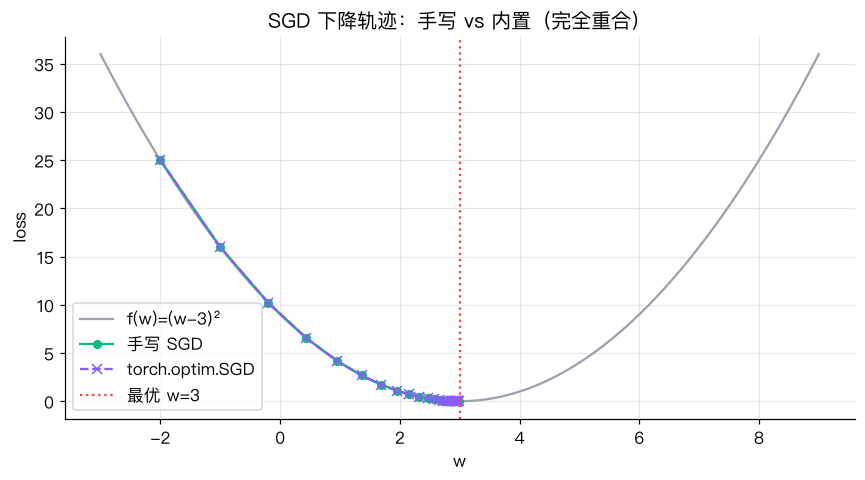

In [19]:
# 一个一维凸函数 f(w) = (w-3)^2，最优解 w=3；比较手写 SGD 与 torch.optim.SGD 的轨迹
def f(w):
    return (w - 3.0) ** 2

lr = 0.1
steps = 25

# ---- 手写 SGD ----
w_manual = torch.tensor([-2.0])
traj_manual = [w_manual.item()]
for _ in range(steps):
    grad = 2 * (w_manual - 3.0)          # df/dw
    w_manual = w_manual - lr * grad      # 手动更新
    traj_manual.append(w_manual.item())

# ---- 内置 torch.optim.SGD ----
w_torch = torch.tensor([-2.0], requires_grad=True)
opt = torch.optim.SGD([w_torch], lr=lr)
traj_torch = [w_torch.item()]
for _ in range(steps):
    opt.zero_grad()                      # 清零累积梯度（第 2 章的坑！）
    loss = f(w_torch)
    loss.backward()                      # 算 grad
    opt.step()                           # 用 grad 更新
    traj_torch.append(w_torch.item())

print("手写 SGD 最终 w:", round(traj_manual[-1], 6))
print("内置 SGD 最终 w:", round(traj_torch[-1], 6))
print("两条轨迹最大差:", max(abs(a - b) for a, b in zip(traj_manual, traj_torch)))

# ---- 画出两条下降轨迹（应完全重合）----
fig, ax = plt.subplots(figsize=(8, 4.5))
ws = torch.linspace(-3, 9, 200)
ax.plot(ws, f(ws), color=COLORS["gray"], lw=1.5, label="f(w)=(w-3)²")
ax.plot(traj_manual, [f(torch.tensor(v)).item() for v in traj_manual],
        "o-", color=COLORS["green"], ms=5, label="手写 SGD")
ax.plot(traj_torch, [f(torch.tensor(v)).item() for v in traj_torch],
        "x--", color=COLORS["purple"], ms=7, label="torch.optim.SGD")
ax.axvline(3, color=COLORS["red"], ls=":", label="最优 w=3")
ax.set_xlabel("w"); ax.set_ylabel("loss"); ax.set_title("SGD 下降轨迹：手写 vs 内置（完全重合）")
ax.legend(); plt.tight_layout(); plt.show()

### 手写 Adam，和 `torch.optim.Adam` 对拍

Adam 在 SGD 基础上，为每个参数维护梯度的**一阶动量** $m$（方向）和**二阶动量** $v$（步长缩放），
并做偏差校正。更新公式：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t,\quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t},\quad \hat v_t = \frac{v_t}{1-\beta_2^t},\quad
\theta_t = \theta_{t-1} - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

照着公式手写，和内置对拍，逐步的参数值应当高度一致。

手写 Adam 最终 w: 0.796505
内置 Adam 最终 w: 0.796505
逐步最大绝对差: 3.5762786865234375e-07  ✅


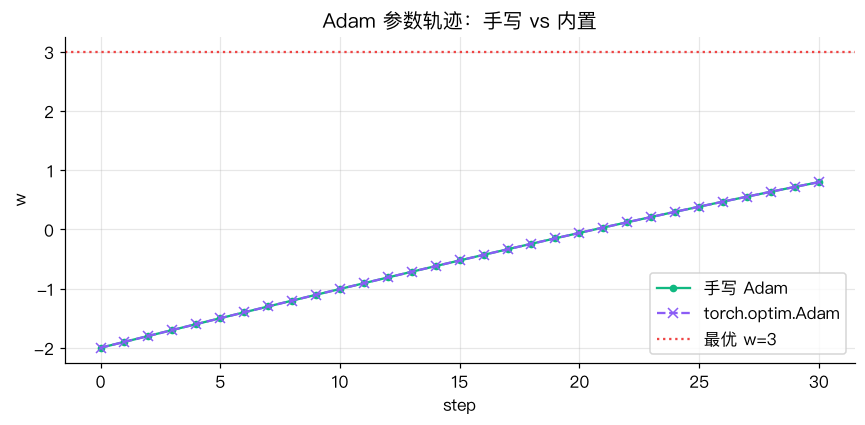

In [20]:
b1, b2, eps_a, lr_a = 0.9, 0.999, 1e-8, 0.1
steps = 30

# ---- 手写 Adam ----
w_m = torch.tensor([-2.0])
m, v = torch.zeros(1), torch.zeros(1)
traj_m = [w_m.item()]
for t in range(1, steps + 1):
    g = 2 * (w_m - 3.0)                       # 梯度
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g * g
    m_hat = m / (1 - b1 ** t)                 # 偏差校正
    v_hat = v / (1 - b2 ** t)
    w_m = w_m - lr_a * m_hat / (v_hat.sqrt() + eps_a)
    traj_m.append(w_m.item())

# ---- 内置 Adam（默认 betas/eps 与上面一致）----
w_t = torch.tensor([-2.0], requires_grad=True)
opt = torch.optim.Adam([w_t], lr=lr_a, betas=(b1, b2), eps=eps_a)
traj_t = [w_t.item()]
for t in range(steps):
    opt.zero_grad()
    loss = (w_t - 3.0) ** 2
    loss.backward()
    opt.step()
    traj_t.append(w_t.item())

print("手写 Adam 最终 w:", round(traj_m[-1], 6))
print("内置 Adam 最终 w:", round(traj_t[-1], 6))
print("逐步最大绝对差:", max(abs(a - b) for a, b in zip(traj_m, traj_t)), " ✅")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(traj_m, "o-", color=COLORS["green"], ms=4, label="手写 Adam")
ax.plot(traj_t, "x--", color=COLORS["purple"], ms=6, label="torch.optim.Adam")
ax.axhline(3, color=COLORS["red"], ls=":", label="最优 w=3")
ax.set_xlabel("step"); ax.set_ylabel("w"); ax.set_title("Adam 参数轨迹：手写 vs 内置")
ax.legend(); plt.tight_layout(); plt.show()

### 常用内置损失

分类几乎总是用 `nn.CrossEntropyLoss`。**关键细节**：它内部已经含了 `LogSoftmax`，
所以模型最后一层应当输出**原始 logits**（不要自己再加 softmax，否则等于做了两次）。
下面验证 `CrossEntropyLoss` = `log_softmax` + `nll_loss`。

In [21]:
logits = torch.randn(5, 3)               # 5 个样本，3 类
target = torch.tensor([0, 2, 1, 0, 2])

ce = nn.CrossEntropyLoss()(logits, target)
manual = F.nll_loss(F.log_softmax(logits, dim=1), target)   # 手动拆开
print("nn.CrossEntropyLoss      :", ce.item())
print("log_softmax + nll_loss   :", manual.item())
print("一致:", torch.allclose(ce, manual), "  —— 所以模型最后别再加 softmax！")

nn.CrossEntropyLoss      : 1.8930860757827759
log_softmax + nll_loss   : 1.8930860757827759
一致: True   —— 所以模型最后别再加 softmax！


## 6 · 训练循环骨架：Dataset / DataLoader / mini-batch

把前面所有零件组装起来，就得到 PyTorch 里**通用的训练循环模板**。先在一个玩具回归任务上跑通它，
把每一步讲清楚，第 7 章再原样套到真实图像数据上。

**数据管道**：`Dataset` 定义「怎么取第 i 个样本」，`DataLoader` 负责**分 batch、打乱、并行加载**。
一次喂一个 mini-batch 而不是整份数据，是现代训练的标准做法（省显存 + 梯度带噪声有助泛化）。

In [38]:
from torch.utils.data import TensorDataset, DataLoader

# 造一个带噪声的三次曲线回归任务：y = 0.5x^3 - x + 噪声
torch.manual_seed(0)
Nx = 256
Xr = torch.linspace(-3, 3, Nx).reshape(-1, 1)
Yr = 0.5 * Xr**3 - Xr + 0.8 * torch.randn(Nx, 1)

ds = TensorDataset(Xr, Yr)                       # 每个样本是 (x_i, y_i)
loader = DataLoader(ds, batch_size=32, shuffle=True)
print("样本总数:", len(ds), "| 每个 batch 大小: 32 | batch 数:", len(loader))
xb, yb = next(iter(loader))
print("一个 batch: X", tuple(xb.shape), " Y", tuple(yb.shape))

样本总数: 256 | 每个 batch 大小: 32 | batch 数: 8
一个 batch: X (32, 1)  Y (32, 1)


### 通用训练循环（**记住这个模板**）

几乎所有 PyTorch 训练都是这五步的循环，务必形成肌肉记忆：

```
for epoch:
    for xb, yb in loader:
        optimizer.zero_grad()      # ① 清零上一步的梯度（否则累积）
        pred = model(xb)           # ② 前向
        loss = loss_fn(pred, yb)   # ③ 算损失
        loss.backward()            # ④ 反向求梯度
        optimizer.step()           # ⑤ 更新参数
```

epoch  40  平均损失 0.7799
epoch  80  平均损失 0.6849
epoch 120  平均损失 0.5898
epoch 160  平均损失 0.5848
epoch 200  平均损失 0.5890


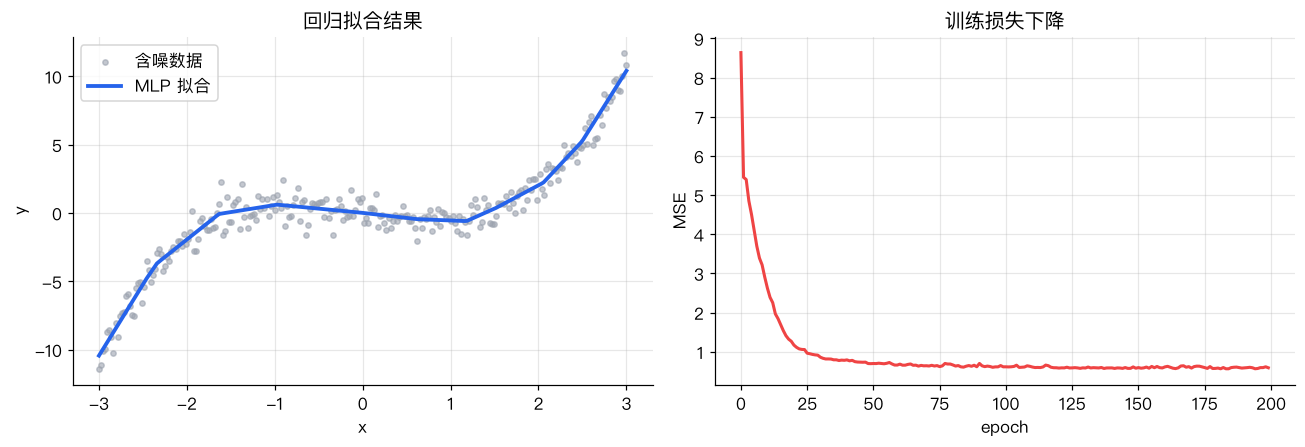

In [23]:
reg = MLP(in_dim=1, hidden=64, out_dim=1).to(device)
opt = torch.optim.Adam(reg.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

Xr_d, Yr_d = Xr.to(device), Yr.to(device)
losses = []
EPOCHS = 200
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()                 # ①
        pred = reg(xb)                  # ②
        loss = loss_fn(pred, yb)        # ③
        loss.backward()                 # ④
        opt.step()                      # ⑤
        epoch_loss += loss.item() * xb.size(0)
    losses.append(epoch_loss / len(ds))
    if (epoch + 1) % 40 == 0:
        print(f"epoch {epoch+1:3d}  平均损失 {losses[-1]:.4f}")

# ---- 可视化：拟合曲线 + 损失下降 ----
reg.eval()
with torch.no_grad():
    yhat = reg(Xr_d).cpu()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.scatter(Xr, Yr, s=12, color=COLORS["gray"], alpha=0.6, label="含噪数据")
ax1.plot(Xr, yhat, color=COLORS["blue"], lw=2.5, label="MLP 拟合")
ax1.set_title("回归拟合结果"); ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.legend()
ax2.plot(losses, color=COLORS["red"], lw=2)
ax2.set_title("训练损失下降"); ax2.set_xlabel("epoch"); ax2.set_ylabel("MSE")
plt.tight_layout(); plt.show()

## 7 · 端到端实战：FashionMNIST 图像分类

现在把所有零件——**Tensor / autograd / nn.Module / 损失 / 优化器 / DataLoader / train-eval**——
组装成一个真实的图像分类器。

**FashionMNIST**：10 类服饰的 28×28 灰度图（T恤/裤子/套头衫/裙子/外套/凉鞋/衬衫/运动鞋/包/短靴），
是 MNIST 的进阶替代品，比手写数字更有挑战。数据由 torchvision 自动下载到 `data/`。

In [24]:
from torchvision import datasets, transforms

# ToTensor: 把 PIL 图像 (0-255) 转成 (1,28,28) 的 float32 张量并归一化到 [0,1]
transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

CLASSES = ["T恤", "裤子", "套头衫", "裙子", "外套",
           "凉鞋", "衬衫", "运动鞋", "包", "短靴"]

print("训练集:", len(train_ds), "张 | 测试集:", len(test_ds), "张")
img0, label0 = train_ds[0]
print("单张图像 shape:", tuple(img0.shape), "| 像素范围:",
      f"[{img0.min():.2f}, {img0.max():.2f}] | 标签:", CLASSES[label0])

训练集: 60000 张 | 测试集: 10000 张
单张图像 shape: (1, 28, 28) | 像素范围: [0.00, 1.00] | 标签: 短靴


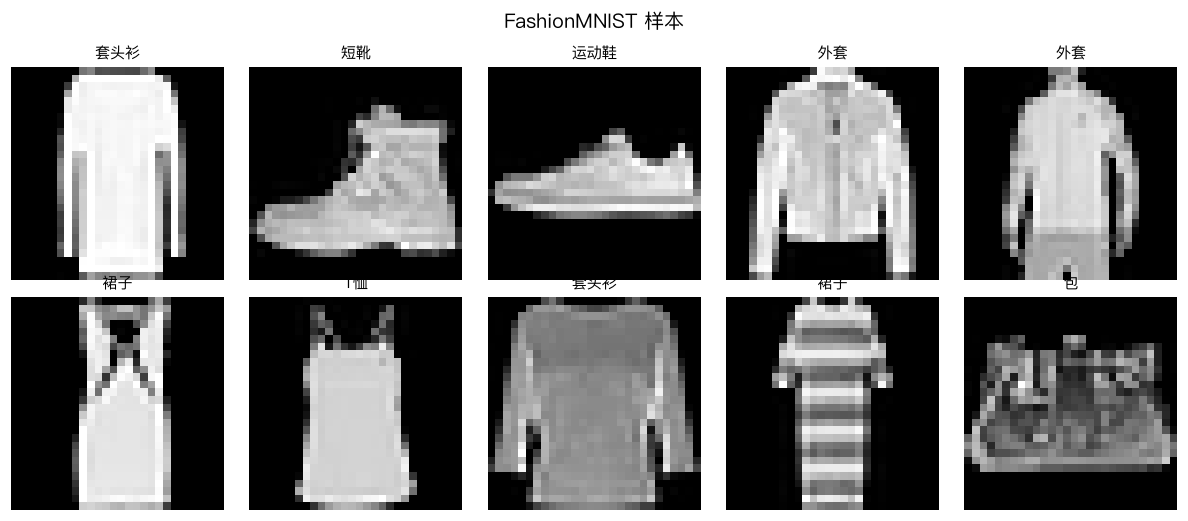

In [25]:
# 看一眼数据长什么样：随机展示 10 张
fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))
for ax, idx in zip(axes.flat, torch.randint(0, len(train_ds), (10,)).tolist()):
    img, lab = train_ds[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASSES[lab], fontsize=10)
    ax.axis("off")
fig.suptitle("FashionMNIST 样本", fontsize=13)
plt.tight_layout(); plt.show()

### 定义模型、损失、优化器

用一个两隐层的 MLP：把 28×28 图像**展平**成 784 维向量，经两层 ReLU，输出 10 个 logits。
（真实项目里图像分类会用 CNN，但这里聚焦「把框架用对」，MLP 已足够跑到 ~88% 准确率。）

In [26]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()            # (B,1,28,28) -> (B,784)
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),     nn.ReLU(),
            nn.Linear(128, 10),                # 输出原始 logits（不加 softmax）
        )

    def forward(self, x):
        return self.net(self.flatten(x))

clf = FashionMLP().to(device)
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)
print(clf)
print("参数量:", sum(p.numel() for p in clf.parameters()))

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
参数量: 235146


### 训练 + 每个 epoch 在测试集评估

注意两个**状态切换**（第 8 章会强调为什么重要）：

- 训练时 `model.train()`：让 Dropout 生效。
- 评估时 `model.eval()` + `with torch.no_grad()`：关掉 Dropout、不建计算图（更快省显存）。

In [27]:
def evaluate(model, loader):
    "在给定数据集上算平均损失和准确率"
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss_sum += loss_fn(logits, yb).item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return loss_sum / total, correct / total

EPOCHS = 8
# StepLR：每 3 个 epoch 把学习率乘 0.5，后期更小步、更稳
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)
hist = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "lr": []}
t0 = time.time()
for epoch in range(EPOCHS):
    clf.train()                                 # 训练模式：Dropout 打开
    running, tr_correct, tr_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = clf(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        running += loss.item() * xb.size(0)
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total += xb.size(0)
    hist["lr"].append(opt.param_groups[0]["lr"])
    scheduler.step()                            # 每个 epoch 末更新学习率
    tr_loss = running / len(train_ds)
    te_loss, te_acc = evaluate(clf, test_loader)
    hist["train_loss"].append(tr_loss)
    hist["train_acc"].append(tr_correct / tr_total)
    hist["test_loss"].append(te_loss)
    hist["test_acc"].append(te_acc)
    print(f"epoch {epoch+1}/{EPOCHS}  lr {hist['lr'][-1]:.4f} | 训练损失 {tr_loss:.4f} | "
          f"测试损失 {te_loss:.4f} | 测试准确率 {te_acc*100:.2f}%")
print(f"\n总耗时 {time.time()-t0:.1f}s  | 设备 {device}")

epoch 1/8  lr 0.0010 | 训练损失 0.5962 | 测试损失 0.4492 | 测试准确率 84.24%
epoch 2/8  lr 0.0010 | 训练损失 0.4041 | 测试损失 0.4106 | 测试准确率 85.02%
epoch 3/8  lr 0.0010 | 训练损失 0.3587 | 测试损失 0.3730 | 测试准确率 86.69%
epoch 4/8  lr 0.0005 | 训练损失 0.3220 | 测试损失 0.3667 | 测试准确率 87.02%
epoch 5/8  lr 0.0005 | 训练损失 0.3091 | 测试损失 0.3452 | 测试准确率 87.81%
epoch 6/8  lr 0.0005 | 训练损失 0.2977 | 测试损失 0.3339 | 测试准确率 87.92%
epoch 7/8  lr 0.0003 | 训练损失 0.2785 | 测试损失 0.3329 | 测试准确率 88.19%
epoch 8/8  lr 0.0003 | 训练损失 0.2722 | 测试损失 0.3240 | 测试准确率 88.42%

总耗时 14.8s  | 设备 mps


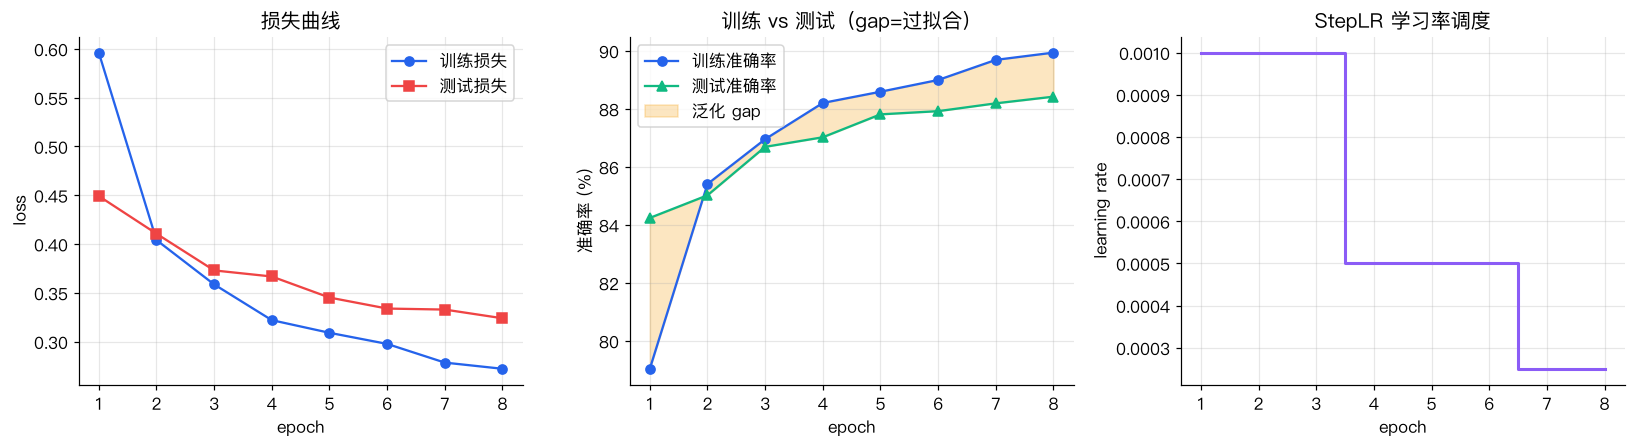

In [28]:
# ---- 学习曲线：损失 / 准确率 / 学习率与过拟合 gap ----
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, hist["train_loss"], "o-", color=COLORS["blue"], label="训练损失")
ax1.plot(ep, hist["test_loss"],  "s-", color=COLORS["red"],  label="测试损失")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_title("损失曲线"); ax1.legend()

# 训练 vs 测试准确率：两条线的间隙就是「泛化 gap」（过拟合程度）
ax2.plot(ep, [a*100 for a in hist["train_acc"]], "o-", color=COLORS["blue"], label="训练准确率")
ax2.plot(ep, [a*100 for a in hist["test_acc"]],  "^-", color=COLORS["green"], label="测试准确率")
ax2.fill_between(ep, [a*100 for a in hist["train_acc"]], [a*100 for a in hist["test_acc"]],
                 color=COLORS["amber"], alpha=0.25, label="泛化 gap")
ax2.set_xlabel("epoch"); ax2.set_ylabel("准确率 (%)"); ax2.set_title("训练 vs 测试（gap=过拟合）"); ax2.legend()

# 学习率随 StepLR 阶梯下降
ax3.step(ep, hist["lr"], where="mid", color=COLORS["purple"], lw=2)
ax3.set_xlabel("epoch"); ax3.set_ylabel("learning rate"); ax3.set_title("StepLR 学习率调度")
plt.tight_layout(); plt.show()

### 混淆矩阵：模型在哪类上最容易搞混？

准确率是一个总数字，**混淆矩阵**能告诉我们错误的结构：哪些类别互相混淆最多。
FashionMLP 通常在「衬衫 vs T恤 vs 套头衫 vs 外套」这几类上纠结（它们视觉上确实相似）。

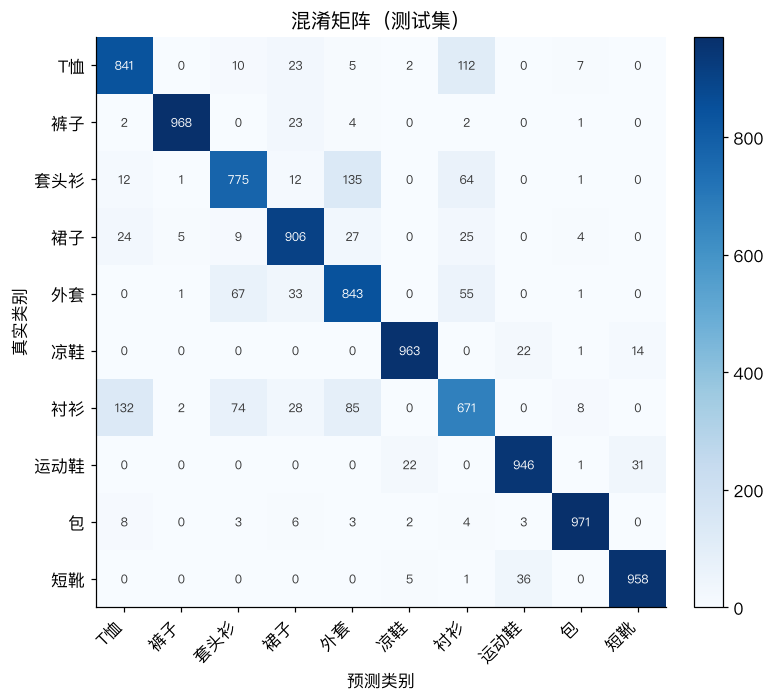

In [29]:
# 收集全部测试集预测，构建 10x10 混淆矩阵
clf.eval()
conf = torch.zeros(10, 10, dtype=torch.int32)
with torch.no_grad():
    for xb, yb in test_loader:
        pred = clf(xb.to(device)).argmax(1).cpu()
        for t, p in zip(yb, pred):
            conf[t, p] += 1

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(conf, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticklabels(CLASSES)
ax.set_xlabel("预测类别"); ax.set_ylabel("真实类别"); ax.set_title("混淆矩阵（测试集）")
for i in range(10):
    for j in range(10):
        v = conf[i, j].item()
        ax.text(j, i, v, ha="center", va="center", fontsize=8,
                color="white" if v > conf.max().item() * 0.5 else "#333")
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.grid(False)
plt.tight_layout(); plt.show()

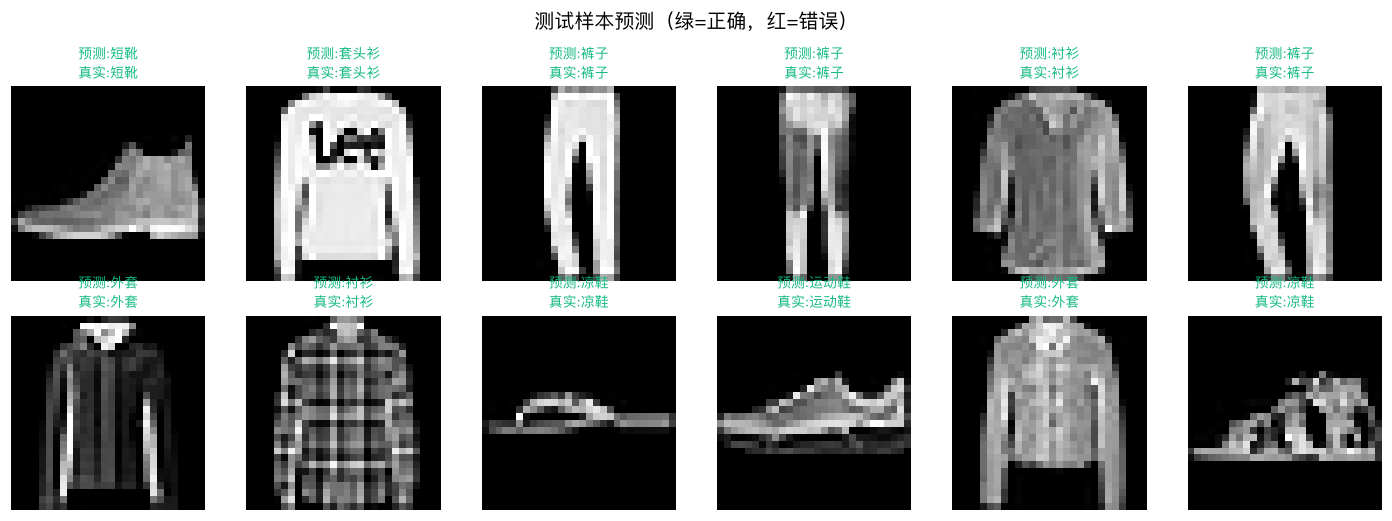

In [30]:
# ---- 直观看几个预测：绿=对，红=错 ----
clf.eval()
imgs, labs = next(iter(test_loader))
with torch.no_grad():
    preds = clf(imgs.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(13, 4.8))
for ax, i in zip(axes.flat, range(12)):
    ax.imshow(imgs[i].squeeze(), cmap="gray"); ax.axis("off")
    ok = preds[i].item() == labs[i].item()
    ax.set_title(f"预测:{CLASSES[preds[i]]}\n真实:{CLASSES[labs[i]]}",
                 fontsize=9, color=COLORS["green"] if ok else COLORS["red"])
fig.suptitle("测试样本预测（绿=正确，红=错误）", fontsize=13)
plt.tight_layout(); plt.show()

## 8 · 权重初始化与梯度消失：为什么深网难训

前面模型都能顺利收敛，但换成**很深**的网络时，训练常常「学不动」。根因之一是**梯度消失/爆炸**：
反向传播时梯度要连乘每一层的局部导数，如果这些因子普遍 <1，梯度指数级衰减到 ~0（消失）；
普遍 >1 则指数级放大（爆炸）。**权重初始化**和**激活函数**共同决定了这些因子的量级。

我们做一个对照实验：一个 20 层的深 MLP，比较三种初始化下**各层梯度范数**的分布：

- **过小初始化**（`N(0, 0.01)`）：梯度层层衰减 → 消失。
- **Xavier/Glorot**：为 `tanh`/`sigmoid` 设计，保持各层方差稳定。
- **Kaiming/He**：为 `ReLU` 设计（PyTorch 对 `nn.Linear` 的默认初始化就基于它）。

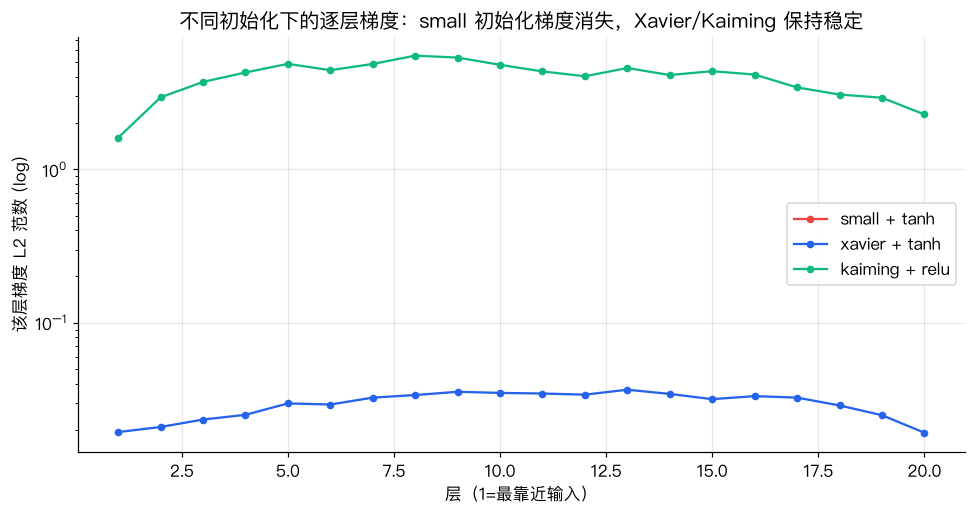

红线在浅层坍缩到极小 = 梯度消失；蓝/绿线各层量级相近 = 健康。


In [54]:
def make_deep(depth=20, width=128, init="kaiming", act="relu"):
    "构造一个 depth 层的深 MLP，用指定方式初始化"
    layers = []
    for _ in range(depth):
        layers.append(nn.Linear(width, width))
        layers.append(nn.ReLU() if act == "relu" else nn.Tanh())
    net = nn.Sequential(*layers)
    for m in net:
        if isinstance(m, nn.Linear):
            if init == "small":
                nn.init.normal_(m.weight, std=0.01)
            elif init == "xavier":
                nn.init.xavier_normal_(m.weight)
            elif init == "kaiming":
                nn.init.kaiming_normal_(m.weight, nonlinearity=act)
            nn.init.zeros_(m.bias)
    return net

def layer_grad_norms(net):
    "前向 + 反向一次，返回每个 Linear 层权重梯度的 L2 范数"
    x = torch.randn(64, 128)
    out = net(x)
    loss = out.pow(2).mean()          # 任意标量损失，只为触发反向
    net.zero_grad(); loss.backward()
    return [m.weight.grad.norm().item() for m in net if isinstance(m, nn.Linear)]

torch.manual_seed(0)
configs = [("small", "tanh", COLORS["red"]),
           ("xavier", "tanh", COLORS["blue"]),
           ("kaiming", "relu", COLORS["green"])]
fig, ax = plt.subplots(figsize=(9, 4.8))
for init, act, color in configs:
    net = make_deep(depth=20, act=act, init=init)
    norms = layer_grad_norms(net)
    ax.plot(range(1, len(norms) + 1), norms, "o-", color=color, ms=4,
            label=f"{init} + {act}")
ax.set_yscale("log")                  # 梯度跨数量级，用对数轴才看得清
ax.set_xlabel("层（1=最靠近输入）"); ax.set_ylabel("该层梯度 L2 范数 (log)")
ax.set_title("不同初始化下的逐层梯度：small 初始化梯度消失，Xavier/Kaiming 保持稳定")
ax.legend(); plt.tight_layout(); plt.show()
print("红线在浅层坍缩到极小 = 梯度消失；蓝/绿线各层量级相近 = 健康。")

## 9 · 卷积网络（CNN）：图像分类的正解

第 7 章把图像**展平**成 784 维向量喂给 MLP——这丢掉了像素的**空间结构**（哪个像素挨着哪个）。
**卷积层 `nn.Conv2d`** 用一个小窗口（kernel）在图上滑动、共享权重，天然利用局部性与平移不变性，
是图像任务的标准做法。核心两件套：

- **`nn.Conv2d(in_ch, out_ch, kernel_size)`**：学 `out_ch` 个卷积核，每个在输入上滑动产生一张特征图。
- **`nn.MaxPool2d(2)`**：每 2×2 取最大值，把特征图**降采样**一半，扩大感受野、减少计算。

我们在同一份 FashionMNIST 上训练一个小 CNN，看它能否超过 MLP 的 ~88%。

In [32]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # (B,32,14,14)
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # (B,64,7,7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn = FashionCNN().to(device)
# 打印每层输出形状，直观看到「空间尺寸缩小、通道数增多」
probe = torch.randn(1, 1, 28, 28).to(device)
print("逐层特征图形状：")
h = probe
for layer in cnn.features:
    h = layer(h)
    print(f"  {layer.__class__.__name__:12s} -> {tuple(h.shape)}")
print("参数量:", sum(p.numel() for p in cnn.parameters()))

逐层特征图形状：
  Conv2d       -> (1, 32, 28, 28)
  ReLU         -> (1, 32, 28, 28)
  MaxPool2d    -> (1, 32, 14, 14)
  Conv2d       -> (1, 64, 14, 14)
  ReLU         -> (1, 64, 14, 14)
  MaxPool2d    -> (1, 64, 7, 7)
参数量: 421642


epoch 1/5  测试准确率 86.30%
epoch 2/5  测试准确率 88.01%
epoch 3/5  测试准确率 90.10%
epoch 4/5  测试准确率 90.16%
epoch 5/5  测试准确率 90.92%
总耗时 9.1s | 设备 mps


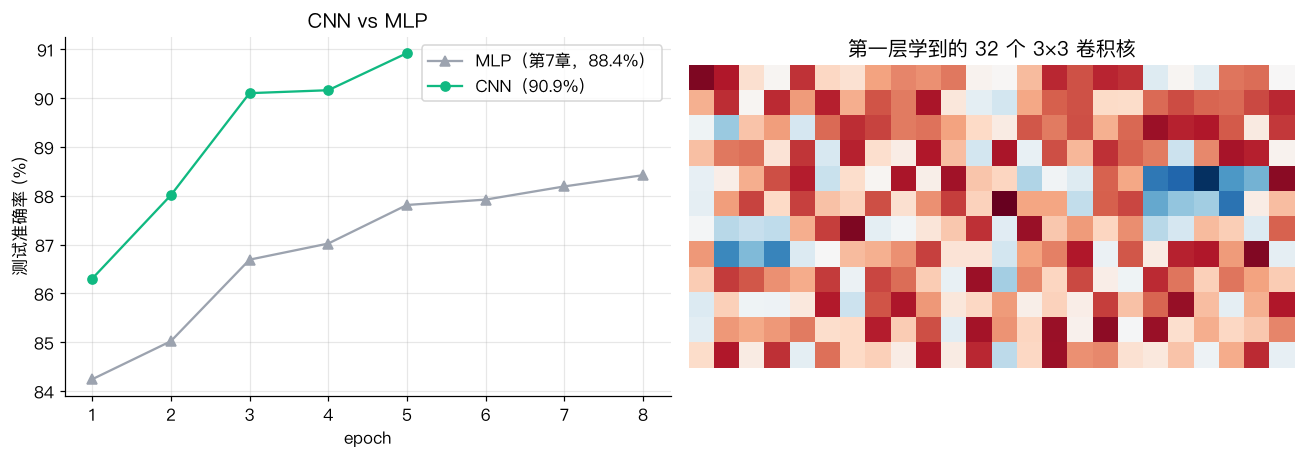

In [33]:
# 训练小 CNN（同样的五步循环，只是模型换了积木）
opt_c = torch.optim.Adam(cnn.parameters(), lr=1e-3)
EPOCHS_C = 5
cnn_acc = []
t0 = time.time()
for epoch in range(EPOCHS_C):
    cnn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_c.zero_grad()
        loss = loss_fn(cnn(xb), yb)
        loss.backward()
        opt_c.step()
    _, acc = evaluate(cnn, test_loader)
    cnn_acc.append(acc)
    print(f"epoch {epoch+1}/{EPOCHS_C}  测试准确率 {acc*100:.2f}%")
print(f"总耗时 {time.time()-t0:.1f}s | 设备 {device}")

# ---- CNN vs MLP 对比 + 第一层卷积核可视化 ----
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.3))
axl.plot(range(1, len(hist["test_acc"]) + 1), [a*100 for a in hist["test_acc"]],
         "^-", color=COLORS["gray"], label=f"MLP（第7章，{hist['test_acc'][-1]*100:.1f}%）")
axl.plot(range(1, EPOCHS_C + 1), [a*100 for a in cnn_acc],
         "o-", color=COLORS["green"], label=f"CNN（{cnn_acc[-1]*100:.1f}%）")
axl.set_xlabel("epoch"); axl.set_ylabel("测试准确率 (%)"); axl.set_title("CNN vs MLP"); axl.legend()

# 第一层学到的 32 个 3x3 卷积核
kernels = cnn.features[0].weight.detach().cpu()   # (32,1,3,3)
grid = torch.zeros(4 * 3, 8 * 3)
for i in range(32):
    r, c = divmod(i, 8)
    grid[r*3:(r+1)*3, c*3:(c+1)*3] = kernels[i, 0]
axr.imshow(grid, cmap="RdBu_r"); axr.axis("off")
axr.set_title("第一层学到的 32 个 3×3 卷积核")
plt.tight_layout(); plt.show()

## 10 · 模型保存与加载：`state_dict` 与 checkpoint

训练好的模型必须能**存下来**、以后**读回来**继续用。PyTorch 的推荐做法是保存 **`state_dict`**
（一个「参数名 → 张量」的字典），而不是整个模型对象——前者可移植、不依赖代码路径。

- **保存**：`torch.save(model.state_dict(), path)`
- **加载**：先**重建同结构模型**，再 `model.load_state_dict(torch.load(path))`
- **checkpoint**：训练中途想能恢复，就把 `model` + `optimizer` + `epoch` 一起存成一个 dict。

In [34]:
import os
os.makedirs("checkpoints", exist_ok=True)

# ---- 1) 只存参数（部署/推理最常用）----
torch.save(cnn.state_dict(), "checkpoints/cnn_weights.pt")
sz = os.path.getsize("checkpoints/cnn_weights.pt") / 1024
print(f"已保存 state_dict：{sz:.1f} KB")

# 重建一个全新模型，加载权重，验证输出与原模型一致
cnn_reloaded = FashionCNN().to(device)
cnn_reloaded.load_state_dict(torch.load("checkpoints/cnn_weights.pt", map_location=device))
cnn_reloaded.eval(); cnn.eval()
xb, _ = next(iter(test_loader))
xb = xb.to(device)
with torch.no_grad():
    same = torch.allclose(cnn(xb), cnn_reloaded(xb), atol=1e-6)
print("重建模型 + 加载权重后，输出与原模型一致:", same, "✅")

# ---- 2) 完整 checkpoint（可续训）----
ckpt = {
    "epoch": EPOCHS_C,
    "model_state": cnn.state_dict(),
    "optim_state": opt_c.state_dict(),
    "test_acc": cnn_acc[-1],
}
torch.save(ckpt, "checkpoints/cnn_full.pt")
loaded = torch.load("checkpoints/cnn_full.pt", map_location=device)
print(f"\ncheckpoint 含: {list(loaded.keys())}")
print(f"从 checkpoint 恢复：epoch={loaded['epoch']}, 记录的准确率={loaded['test_acc']*100:.2f}%")
print("续训时：model.load_state_dict + optimizer.load_state_dict，再从 epoch+1 继续。")

已保存 state_dict：1650.8 KB
重建模型 + 加载权重后，输出与原模型一致: True ✅

checkpoint 含: ['epoch', 'model_state', 'optim_state', 'test_acc']
从 checkpoint 恢复：epoch=5, 记录的准确率=90.92%
续训时：model.load_state_dict + optimizer.load_state_dict，再从 epoch+1 继续。


## 11 · 常见陷阱速查（新手最容易栽的坑）

把踩过的坑集中列出来，配「错误 vs 正确」对照。

| # | 陷阱 | 后果 | 正确做法 |
|---|------|------|----------|
| 1 | 忘了 `optimizer.zero_grad()` | 梯度累积，训练发散 | 每个 batch 更新前清零 |
| 2 | 用 `loss` 而非 `loss.item()` 累加 | 整张计算图被留住，显存爆炸 | 记录标量时 `.item()` |
| 3 | 评估时忘 `model.eval()` | Dropout/BN 仍在训练态，指标失真 | 评估前 `eval()`，之后记得切回 `train()` |
| 4 | 评估/推理不加 `torch.no_grad()` | 白建计算图，慢且费显存 | 推理包在 `with torch.no_grad()` |
| 5 | 模型和数据不在同一 `device` | 直接 RuntimeError | 数据 `.to(device)`，模型也 `.to(device)` |
| 6 | 最后一层又加 `softmax` 再用 `CrossEntropyLoss` | 相当于做两次，训练变差 | 输出原始 logits |
| 7 | 就地操作 `x += 1` 破坏 autograd 需要的值 | backward 报错或结果错 | 需要梯度时用非就地写法 |

下面用可运行的代码演示其中最典型的几个，并把最致命的「忘记 zero_grad」画成发散曲线。

In [35]:
# 陷阱 2 演示：用 loss（张量）累加 vs 用 loss.item()（标量）
w = torch.tensor([1.0], requires_grad=True)

bad = 0            # 累加张量：会把每步计算图都挂住
for _ in range(3):
    loss = (w * 2) ** 2
    bad = bad + loss          # bad 变成带 grad_fn 的张量，图不断变大
print("用张量累加: type =", type(bad).__name__, "| requires_grad =", bad.requires_grad,
      " <- 计算图被留住，显存隐患")

good = 0.0
for _ in range(3):
    loss = (w * 2) ** 2
    good = good + loss.item() # 只取 Python 浮点数，图可被释放
print("用 .item() 累加: type =", type(good).__name__, "| 值 =", good, " ✅")

用张量累加: type = Tensor | requires_grad = True  <- 计算图被留住，显存隐患
用 .item() 累加: type = float | 值 = 12.0  ✅


In [36]:
# 陷阱 5 演示：设备不一致直接报错（仅当有非 CPU 设备时才能触发）
if device.type != "cpu":
    m = nn.Linear(3, 2).to(device)     # 模型在 GPU/MPS
    x_cpu = torch.randn(4, 3)          # 数据在 CPU
    try:
        m(x_cpu)
    except RuntimeError as e:
        print("设备不一致报错 ->", str(e).splitlines()[0])
    print("修复：x.to(device) 后再前向 ->", tuple(m(x_cpu.to(device)).shape), "✅")
else:
    print("当前是 CPU 环境，无法演示跨设备报错；有 GPU/MPS 时把数据/模型放同一设备即可。")

设备不一致报错 -> Tensor for argument input is on cpu but expected on mps
修复：x.to(device) 后再前向 -> (4, 2) ✅


### 陷阱 1 可视化：忘了 `zero_grad()` 会怎样

这是最致命的坑。同一个回归任务，唯一区别是**每步是否 `zero_grad()`**：
不清零时梯度不断累加，等效学习率越滚越大，损失直接**发散**。

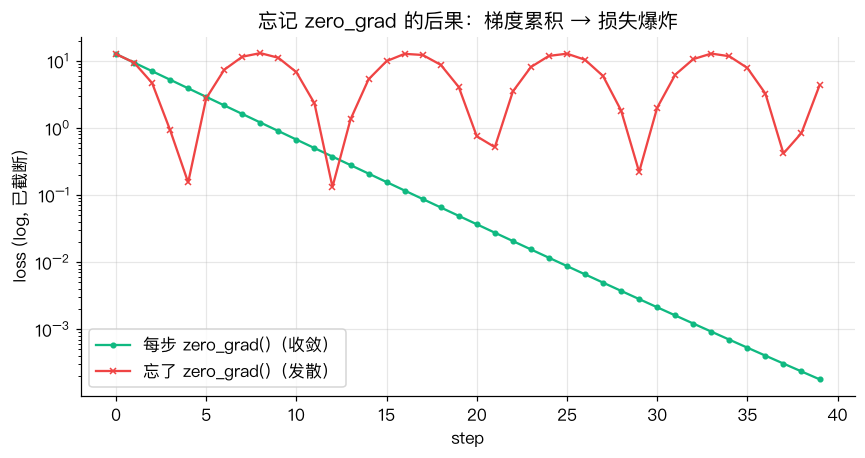

In [37]:
# 对比：清零 vs 不清零梯度，其余完全相同
def train_toy(zero_grad_each_step):
    torch.manual_seed(0)
    m = nn.Linear(1, 1)
    o = torch.optim.SGD(m.parameters(), lr=0.05)
    xs = torch.linspace(-2, 2, 64).reshape(-1, 1)
    ys = 3 * xs + 1
    curve = []
    for _ in range(40):
        if zero_grad_each_step:
            o.zero_grad()
        loss = ((m(xs) - ys) ** 2).mean()
        loss.backward()
        o.step()
        curve.append(min(loss.item(), 1e4))   # 截断，避免 inf 破坏绘图
    return curve

good = train_toy(True)
bad = train_toy(False)

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(good, "o-", color=COLORS["green"], ms=3, label="每步 zero_grad()（收敛）")
ax.plot(bad, "x-", color=COLORS["red"], ms=4, label="忘了 zero_grad()（发散）")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("loss (log, 已截断)")
ax.set_title("忘记 zero_grad 的后果：梯度累积 → 损失爆炸"); ax.legend()
plt.tight_layout(); plt.show()

## 小结

你已经把 PyTorch 从底层机制到实战闭环拆开看了个通透：

- **Tensor**（创建/索引/reshape/**广播**）是带设备与自动求导能力的多维数组。
- **autograd** 前向动态建图、`backward()` 反向套链式法则；梯度**累积**，故要 `zero_grad`。
- 我们手写了**反向传播、SGD、Adam、Linear** 并与内置**逐位对拍**，用**数值梯度**校验——框架没有魔法。
- **nn.Module** 统一管理参数；**训练循环**永远是「清零→前向→算损失→反向→更新」五步。
- **优化实战三件套**：`lr_scheduler` 调度学习率、train/test **泛化 gap** 看过拟合、**权重初始化**决定深网能否训得动（梯度消失/爆炸）。
- **CNN**（`Conv2d`+`MaxPool2d`）利用空间结构，在 FashionMNIST 上超过 MLP；换模型只是「换积木」。
- **保存/加载** 用 `state_dict` 与 checkpoint，让训练成果可部署、可续训。

**下一步建议**：给 CNN 加 `BatchNorm2d` 与数据增强（`transforms.RandomHorizontalFlip` 等），
或换用官方预训练模型做迁移学习——训练循环骨架几乎不变。

**参考资料**
- PyTorch 官方文档 <https://pytorch.org/docs/stable/index.html>
- 官方 *Learn the Basics* <https://pytorch.org/tutorials/beginner/basics/intro.html>
- He et al. (2015). *Delving Deep into Rectifiers.*（Kaiming 初始化）arXiv:1502.01852.
- Xiao et al. (2017). *Fashion-MNIST.* arXiv:1708.07747.